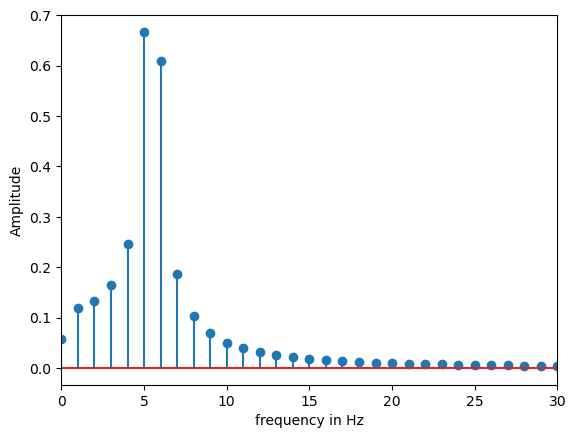

In [9]:
import numpy as np
import matplotlib.pyplot as plt
#the example with spectral leakage
sample_rate = 1000
duration = 1.0

N = int(sample_rate * duration)
time = np.arange(N)/sample_rate

signal = np.sin(2 * np.pi * 5.5 * time)

spectrum = np.fft.rfft(signal)

frequencies = np.fft.rfftfreq(N, d = 1/sample_rate)

magnitude = np.abs(spectrum) / N #|X[k]| = A*N/2
#here the magniude is actually scaled amp 

magnitude[1:-1] *= 2

plt.stem(frequencies , magnitude)
plt.xlim(0,30)
plt.xlabel("frequency in Hz")
plt.ylabel("Amplitude")
plt.show()

#shows amplitude spread out from its original value of 1

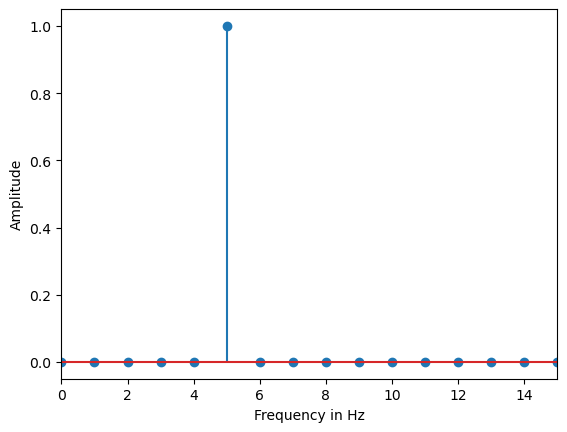

In [5]:
import numpy as np
import matplotlib.pyplot as plt
#exact peaks no spectral leakage
sample_rate = 1000
duration = 1.0

N = int(sample_rate * duration)

time = np.arange(N) / sample_rate

signal = np.sin(
    2 * np.pi * 5 * time
)

spectrum = np.fft.rfft(signal)

frequencies = np.fft.rfftfreq(
    N,
    d=1 / sample_rate
)

magnitude = np.abs(spectrum) / N

magnitude[1:-1] *= 2

plt.stem(
    frequencies,
    magnitude
)

plt.xlim(0, 15)

plt.xlabel("Frequency in Hz")
plt.ylabel("Amplitude")

plt.show()

In [ ]:

"""
6. Important intuition
Leakage does not mean the original signal suddenly contains all those frequencies.
The original signal still contains only:
5.5Hz
The spread is caused by the finite observation window.
So,
leakage is an analysis artifact and not necessarily a property of the original signal.
"""

In [11]:
#fixing the leakage using hann window
signal = np.sin(2 * np.pi * 5.5 * time)
window = np.hanning(N)
windowed_signal = signal * window

In [12]:
spectrum = np.fft.rfft(
    windowed_signal
)

magnitude = np.abs(spectrum)

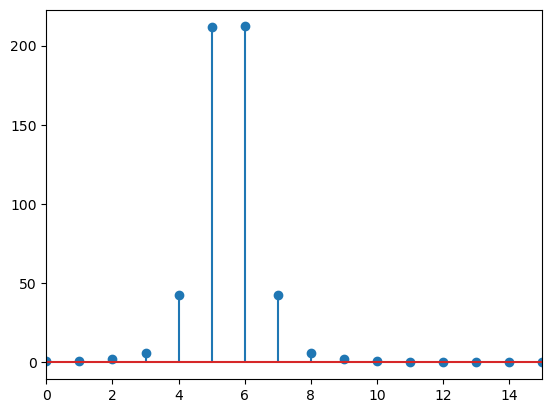

In [13]:
plt.stem(
    frequencies,
    magnitude
)

plt.xlim(0, 15)

plt.show()
#tradeoff lower side 0 to 4 and 8 to 14 leakage reuced but around main lobe 4-8 it increased

In [ ]:
"""
A window's frequency response has:
main lobe
side lobes
The main lobe is the central peak.
Side lobes are smaller peaks around it.
Good windows try to balance:
narrow main lobe
low side lobes
These correspond roughly to:
frequency resolution
leakage suppression
"""

"""
14. Why windowing matters so much in audio
Real audio almost never contains frequencies that align perfectly with FFT bins.
For example, speech may contain:

f=237.4 Hz 
while your FFT bins might be:

234.375, 250...So leakage is unavoidable in practical signals.
That's why STFT and spectrogram pipelines usually apply a window such as Hann to every frame before computing the FFT.
"""

In [ ]:
"""
15. One subtle point: magnitude changes after windowing
When you multiply by a window, you reduce the average amplitude of the signal.
So raw FFT magnitude after windowing becomes smaller.
For example, a Hann window has a coherent gain of about:0.5
So if you want accurate amplitude estimation, you should compensate for the window.

In [ ]:
magnitude = np.abs(spectrum)

amplitude = (
    2 * magnitude
    / np.sum(window)
)

#sigma(window) < N
#instead of 2 * magnitude / N 

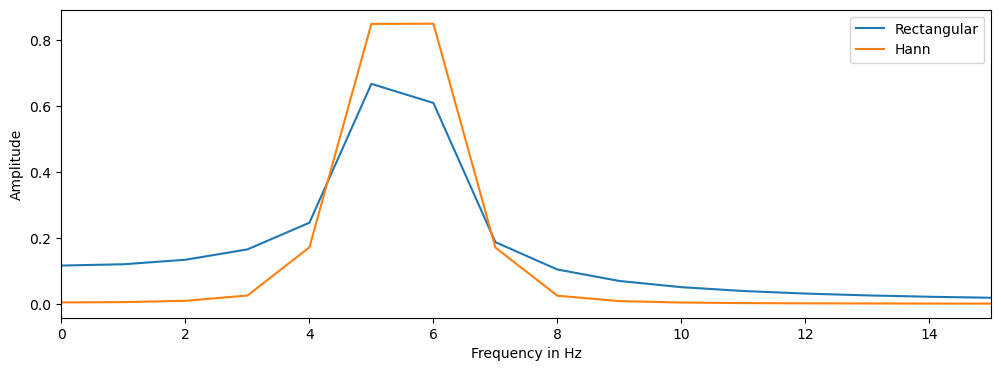

In [14]:
import numpy as np
import matplotlib.pyplot as plt

sample_rate = 1000
duration = 1.0

N = int(
    sample_rate * duration
)

time = np.arange(N) / sample_rate

signal = np.sin(
    2 * np.pi * 5.5 * time
)

frequencies = np.fft.rfftfreq(
    N,
    d=1 / sample_rate
)

# No window
spectrum_rect = np.fft.rfft(
    signal
)

magnitude_rect = (
    2 * np.abs(spectrum_rect) / N
)

# Hann window
window = np.hanning(N)

windowed_signal = (
    signal * window
)

spectrum_hann = np.fft.rfft(
    windowed_signal
)

magnitude_hann = (
    2 * np.abs(spectrum_hann)
    / np.sum(window)
)

plt.figure(figsize=(12, 4))

plt.plot(
    frequencies,
    magnitude_rect,
    label="Rectangular"
)

plt.plot(
    frequencies,
    magnitude_hann,
    label="Hann"
)

plt.xlim(0, 15)

plt.xlabel("Frequency in Hz")
plt.ylabel("Amplitude")

plt.legend()

plt.show()